In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn import metrics, tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
#Loading the data
bank_data = pd.read_csv('Bank_Personal_Loan_Modelling.csv')

In [4]:
#Preview of the data
bank_data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [5]:
#Checking to see if there any null values
#No Null or Missing Values
sum(bank_data.isnull().values)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [6]:
#Deleting duplicates in the dataset
#Also no duplicates in this dataset
bank_data.drop_duplicates()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [7]:
#Cleaning the data
#Any columns with 0 or 1 as values will contain 'No' or 'Yes', respectively
def yes_or_no(x):
    match x:
        case 0:
            return 'No'
        case 1:
            return 'Yes'

#For education level
#1 represents Undergrad
#2 represents Postgrad
#3 represents Advanced/Professional Degree
def education_level (x):
    match x:
        case 1:
            return 'Undergrad'
        case 2:
            return 'Postgrad'
        case 3:
            return 'Advanced/Professional Degree'

#Preview of Cleaned Data
bank_data['Income'] = (bank_data['Income']*1000).astype(float)
bank_data['CCAvg'] = (bank_data['CCAvg']*1000).astype(float)
bank_data['Education'] = bank_data['Education'].apply(education_level)
bank_data['Mortgage'] = (bank_data['Mortgage']*1000).astype(float)
bank_data['Personal Loan'] = bank_data['Personal Loan'].apply(yes_or_no)
bank_data['Securities Account'] = bank_data['Securities Account'].apply(yes_or_no)
bank_data['CD Account'] = bank_data['CD Account'].apply(yes_or_no)
bank_data['Online'] = bank_data['Online'].apply(yes_or_no)
bank_data['CreditCard'] = bank_data['CreditCard'].apply(yes_or_no)
bank_data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49000.0,91107,4,1600.0,Undergrad,0.0,No,Yes,No,No,No
1,2,45,19,34000.0,90089,3,1500.0,Undergrad,0.0,No,Yes,No,No,No
2,3,39,15,11000.0,94720,1,1000.0,Undergrad,0.0,No,No,No,No,No
3,4,35,9,100000.0,94112,1,2700.0,Postgrad,0.0,No,No,No,No,No
4,5,35,8,45000.0,91330,4,1000.0,Postgrad,0.0,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40000.0,92697,1,1900.0,Advanced/Professional Degree,0.0,No,No,No,Yes,No
4996,4997,30,4,15000.0,92037,4,400.0,Undergrad,85000.0,No,No,No,Yes,No
4997,4998,63,39,24000.0,93023,2,300.0,Advanced/Professional Degree,0.0,No,No,No,No,No
4998,4999,65,40,49000.0,90034,3,500.0,Postgrad,0.0,No,No,No,Yes,No


In [8]:
#Trimming the data, specifically the numerically important ones
for col in ["Income", "CCAvg", "Mortgage"]:
    Q1 = bank_data[col].quantile(0.25)
    Q3 = bank_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    bank_data[col] = bank_data[col].clip(lower, upper)
bank_data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49000.0,91107,4,1600.0,Undergrad,0.0,No,Yes,No,No,No
1,2,45,19,34000.0,90089,3,1500.0,Undergrad,0.0,No,Yes,No,No,No
2,3,39,15,11000.0,94720,1,1000.0,Undergrad,0.0,No,No,No,No,No
3,4,35,9,100000.0,94112,1,2700.0,Postgrad,0.0,No,No,No,No,No
4,5,35,8,45000.0,91330,4,1000.0,Postgrad,0.0,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40000.0,92697,1,1900.0,Advanced/Professional Degree,0.0,No,No,No,Yes,No
4996,4997,30,4,15000.0,92037,4,400.0,Undergrad,85000.0,No,No,No,Yes,No
4997,4998,63,39,24000.0,93023,2,300.0,Advanced/Professional Degree,0.0,No,No,No,No,No
4998,4999,65,40,49000.0,90034,3,500.0,Postgrad,0.0,No,No,No,Yes,No


In [9]:
#Engineered three features: 
    #High_CC_Usage to see if customer CCAvg is higher than median
    #Total_Debt which is a sum of Annual CC Spending and Mortgage of a customer
    #Debt_Income_Ratio, which is a ratio between total_debt and income of a customer
bank_data["High_CC_Usage"] = (bank_data["CCAvg"] > bank_data["CCAvg"].median()).astype(int).apply(yes_or_no)
bank_data["Total_Debt"] = bank_data["Mortgage"] + (bank_data["CCAvg"]*12)
bank_data["Debt_Income_Ratio"] = ((bank_data["Mortgage"] + (bank_data["CCAvg"]*12)) / (bank_data["Income"]))*100

In [10]:
bank_data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,High_CC_Usage,Total_Debt,Debt_Income_Ratio
0,1,25,1,49000.0,91107,4,1600.0,Undergrad,0.0,No,Yes,No,No,No,Yes,19200.0,39.183673
1,2,45,19,34000.0,90089,3,1500.0,Undergrad,0.0,No,Yes,No,No,No,No,18000.0,52.941176
2,3,39,15,11000.0,94720,1,1000.0,Undergrad,0.0,No,No,No,No,No,No,12000.0,109.090909
3,4,35,9,100000.0,94112,1,2700.0,Postgrad,0.0,No,No,No,No,No,Yes,32400.0,32.400000
4,5,35,8,45000.0,91330,4,1000.0,Postgrad,0.0,No,No,No,No,Yes,No,12000.0,26.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40000.0,92697,1,1900.0,Advanced/Professional Degree,0.0,No,No,No,Yes,No,Yes,22800.0,57.000000
4996,4997,30,4,15000.0,92037,4,400.0,Undergrad,85000.0,No,No,No,Yes,No,No,89800.0,598.666667
4997,4998,63,39,24000.0,93023,2,300.0,Advanced/Professional Degree,0.0,No,No,No,No,No,No,3600.0,15.000000
4998,4999,65,40,49000.0,90034,3,500.0,Postgrad,0.0,No,No,No,Yes,No,No,6000.0,12.244898


In [11]:
#Data summary
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   float64
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   object 
 8   Mortgage            5000 non-null   float64
 9   Personal Loan       5000 non-null   object 
 10  Securities Account  5000 non-null   object 
 11  CD Account          5000 non-null   object 
 12  Online              5000 non-null   object 
 13  CreditCard          5000 non-null   object 
 14  High_CC_Usage       5000 non-null   object 
 15  Total_Debt          5000 non-null   float64
 16  Debt_I

In [12]:
#Statistics of the data
bank_data.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Mortgage,Total_Debt,Debt_Income_Ratio
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73617.40000,93152.503000,2.396400,1831.338000,50494.700000,72470.756000,125.891514
std,1443.520003,11.463166,11.467954,45626.12153,2121.852197,1.147663,1452.215031,83005.401037,85972.426242,173.627922
min,1.000000,23.000000,-3.000000,8000.00000,9307.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39000.00000,91911.000000,1.000000,700.000000,0.000000,12000.000000,24.246535
50%,2500.500000,45.000000,20.000000,64000.00000,93437.000000,2.000000,1500.000000,0.000000,28800.000000,43.034483
75%,3750.250000,55.000000,30.000000,98000.00000,94608.000000,3.000000,2500.000000,101000.000000,115000.000000,183.257576
max,5000.000000,67.000000,43.000000,186500.00000,96651.000000,4.000000,5200.000000,252500.000000,314900.000000,1332.500000


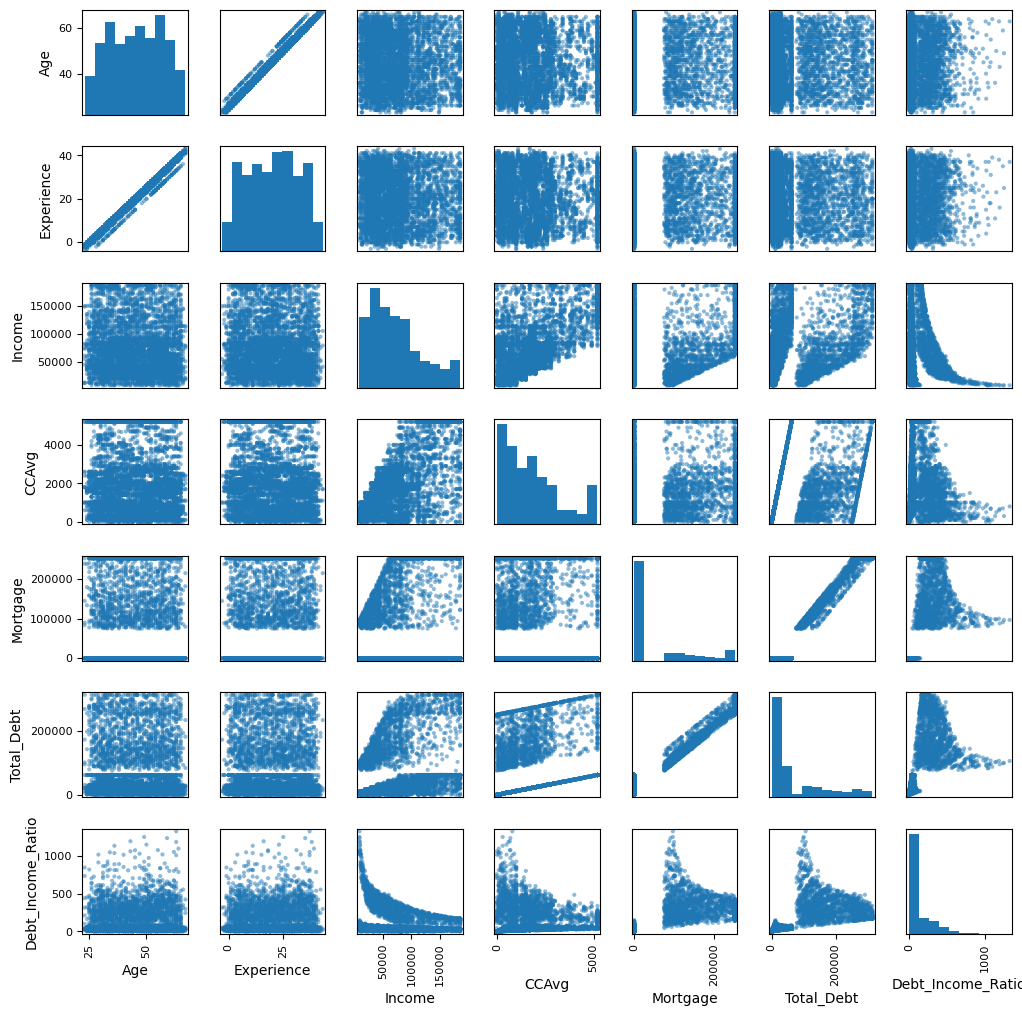

In [13]:
#Correlation Matrix of the Dataset
features = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage', 'Total_Debt', 'Debt_Income_Ratio']

pd.plotting.scatter_matrix(bank_data[features], figsize=(12, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

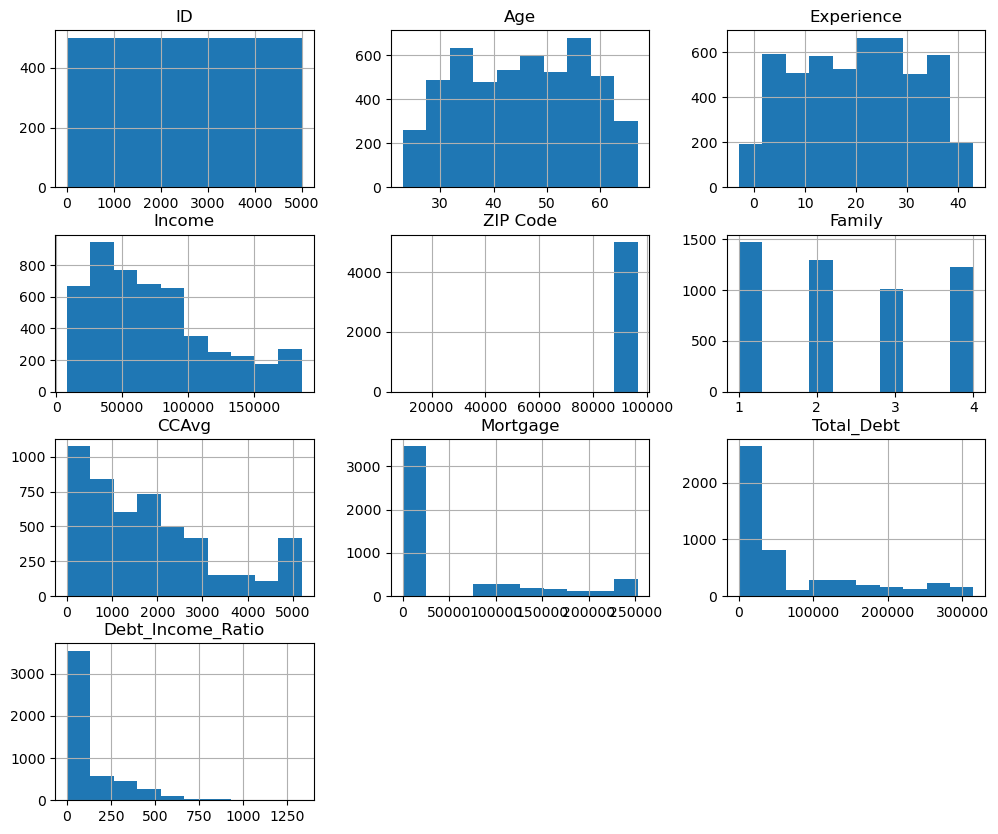

In [14]:
#Histograms of the Data
bank_data.hist(figsize=(12, 10))
plt.show()

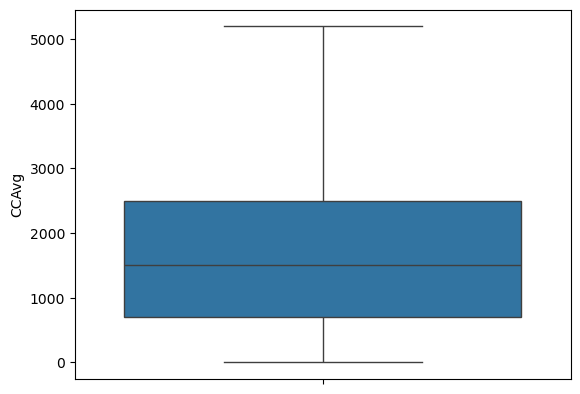

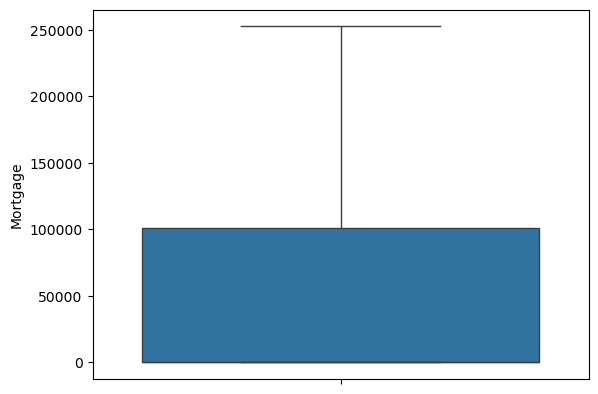

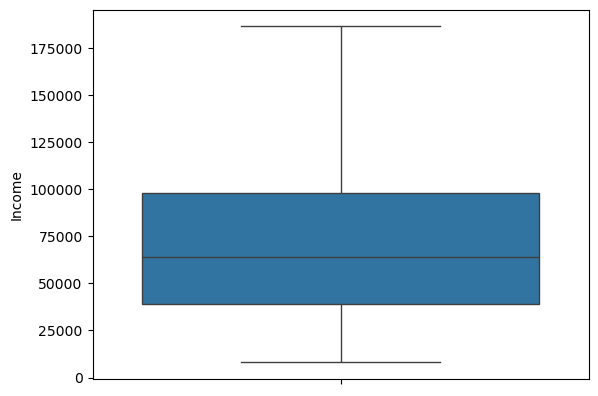

In [15]:
#Boxplot of the numerically siginificant data
sns.boxplot(data=bank_data['CCAvg'])
plt.show()
sns.boxplot(data=bank_data['Mortgage'])
plt.show()
sns.boxplot(data=bank_data['Income'])
plt.show()

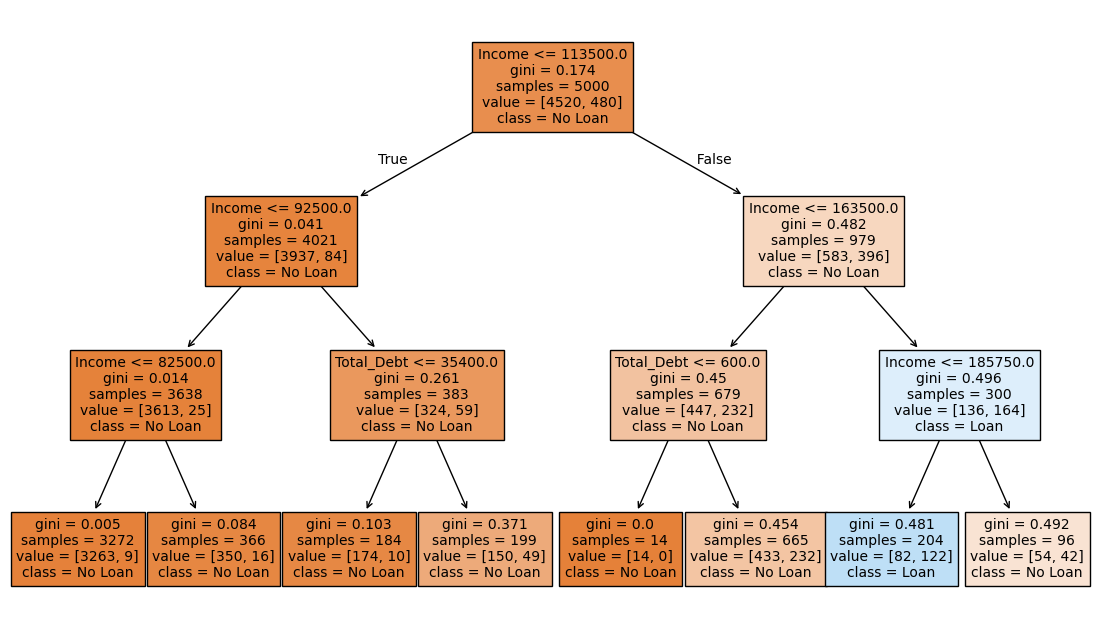

In [16]:
#Supervised Learning: Decision Tree 
#between Personal Loan (Target/Output Feature) and Debt_Income_Ratio (Input feature)
classes = np.sort(bank_data["Personal Loan"].unique())
classnames = ["No Loan" if c == 'No' else "Loan" for c in classes]

y = bank_data['Personal Loan']

# Save input features as x
X = bank_data[['Income', 'Total_Debt']]

# Initialize the model
classtreeModel = DecisionTreeClassifier(max_depth=3)

# Fit the model
classtreeModel = classtreeModel.fit(X, y)

plt.figure(figsize=[14, 8])

tree.plot_tree(classtreeModel, feature_names=X.columns, class_names=classnames, filled=True, fontsize=10)
plt.show()

[Text(0.5, 0.875, 'Family <= 2.5\ngini = 0.176\nsamples = 2370\nvalue = [3385, 365]\nclass = No Loan'),
 Text(0.25, 0.625, 'Education_Undergrad <= 0.5\ngini = 0.132\nsamples = 1335\nvalue = [1929, 148]\nclass = No Loan'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Total_Debt <= 298100.0\ngini = 0.233\nsamples = 676\nvalue = [905, 141]\nclass = No Loan'),
 Text(0.0625, 0.125, 'gini = 0.213\nsamples = 665\nvalue = [904, 125]\nclass = No Loan'),
 Text(0.1875, 0.125, 'gini = 0.111\nsamples = 11\nvalue = [1, 16]\nclass = Loan'),
 Text(0.375, 0.375, 'CD Account_Yes <= 0.5\ngini = 0.013\nsamples = 659\nvalue = [1024, 7]\nclass = No Loan'),
 Text(0.3125, 0.125, 'gini = 0.004\nsamples = 630\nvalue = [980.0, 2.0]\nclass = No Loan'),
 Text(0.4375, 0.125, 'gini = 0.183\nsamples = 29\nvalue = [44, 5]\nclass = No Loan'),
 Text(0.75, 0.625, 'Experience <= 23.5\ngini = 0.226\nsamples = 1035\nvalue = [1456, 217]\nclass = No Loan'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'CD Account_

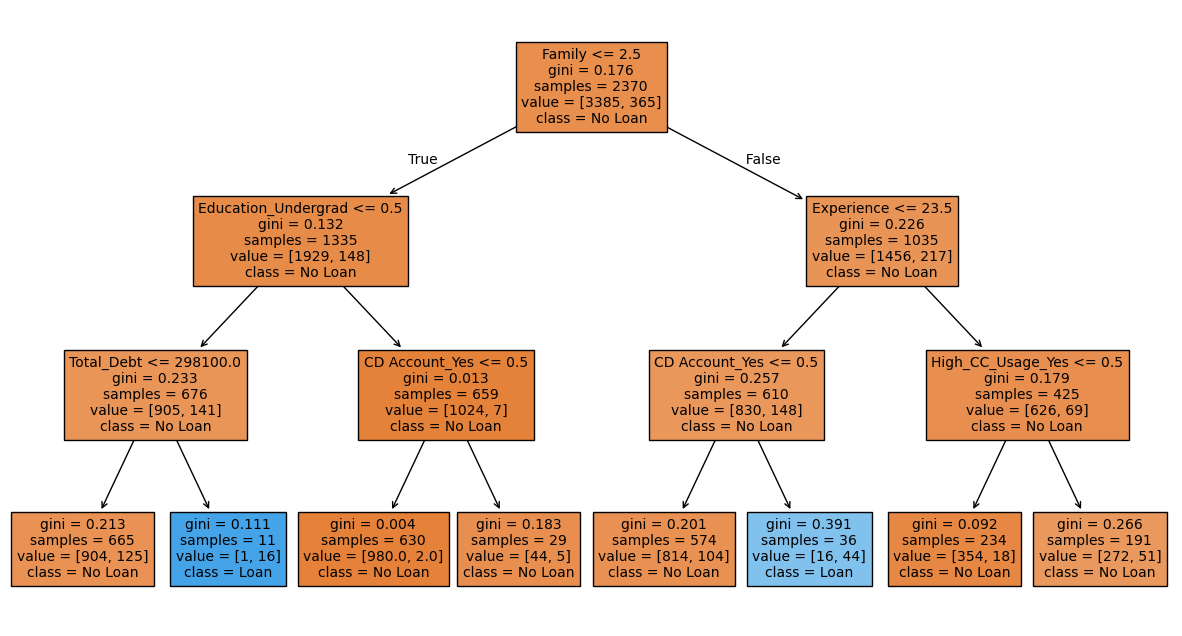

In [17]:
#Supervised Learning: Random Classification Forest
classes = np.sort(bank_data["Personal Loan"].unique())
classnames = ["No Loan" if c == 'No' else "Loan" for c in classes]

# y = output features
y = bank_data['Personal Loan']

# X = input features
X = bank_data.drop('Personal Loan', axis=1)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Initialize the random forest model
randoForest = RandomForestClassifier(max_depth=3, max_features='sqrt', random_state=99)

# Fit the random forest model on the training data
randoForest.fit(X_train, y_train)

# Save the first random forest tree as singleTree
singleTree = randoForest.estimators_[0]

# Set image size
plt.figure(figsize=[15, 8])

tree.plot_tree(singleTree, feature_names=X.columns,  class_names=classnames, filled=True, fontsize=10)


/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


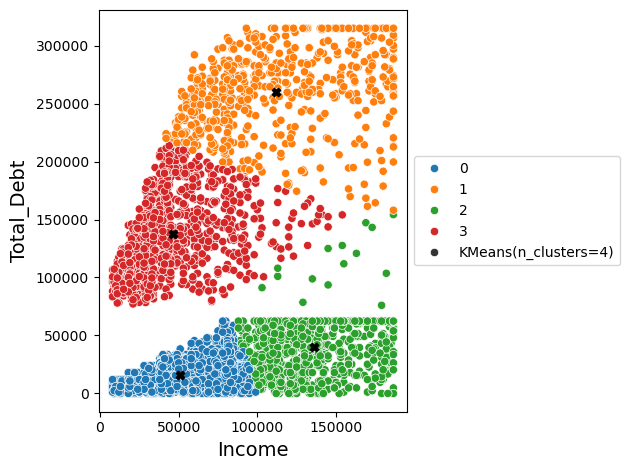

In [18]:
#Unsupervised Learning: K-Means Clustering
#Categorizing by Income and Total Debt into 4 clusters
#Each cluster has a centroid 

clusters = KMeans(n_clusters=4)
clusters.fit(bank_data[['Income', 'Total_Debt']])

centroids = clusters.cluster_centers_
bank_data['Cluster'] = clusters.labels_

p = sns.scatterplot(
    data=bank_data, x='Income', y='Total_Debt', hue='Cluster', style=clusters, palette="tab10"
)
p.set_xlabel('Income', fontsize=14);
p.set_ylabel('Total_Debt', fontsize=14);

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

plt.scatter(x=centroids[0, 0], y=centroids[0, 1], c='black', marker='X')
plt.scatter(x=centroids[1, 0], y=centroids[1, 1], c='black', marker='X')
plt.scatter(x=centroids[2, 0], y=centroids[2, 1], c='black', marker='X')
plt.scatter(x=centroids[3, 0], y=centroids[3, 1], c='black', marker='X')
plt.show()

In [19]:
#Final Report
#Based on my findings, those who are likely to be approved for a loan are those who have high income, preferably at most 
#$185,750. It also shows that a rare amount of people with a moderate total debt (credit card payments and mortgage), but still with a high income
#of at least $163,500 are likely to approved for loans as well 
#However, this is from the decision tree that only focuses on total_debt and income as its input features
#Things got a little complicated as I implemented the random forrest classifier to observe any other trends
#Based on the findings, a customer with less than or equal to 2.5 family members who is a above an undergrad in education level and with a total
#debt higher than $298,100 will be approved of a loan.
#A customer with greater than 2.5 family members, who also has at most 23.5 years of 
#experience and with a credit card account will also be approved of a loan
#In my opinion, I believe the first decision tree has more accurate findings and calculations in who approves of a loan
#, given it contains financial data that a bank is more likely to factor when approving a customer for a loan